<a href="https://colab.research.google.com/github/NdamageEsther/Front-End/blob/main/PersonalFitness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub
import os
os.makedirs("data", exist_ok=True); os.makedirs("model", exist_ok=True)

In [2]:
%%writefile fitness_utils.py
import kagglehub, shutil, glob
path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")
shutil.copy(glob.glob(path + "/*.csv")[0], "data/gym_members_exercise_tracking.csv")
print("Dataset ready")

Writing fitness_utils.py


In [3]:
%%writefile fitness_utils.py
import re
import numpy as np
import pandas as pd

GOALS = ["Lose Weight", "Gain Weight", "Build Muscle", "Maintain Weight"]
ACTIVITY_LEVELS = {            # label: (workouts per week, experience level 1-3)
    "Low (1-2 days/week)": (2, 1),
    "Moderate (3-4 days/week)": (3, 2),
    "High (5+ days/week)": (5, 3),
}
TDEE_FACTOR = {"Low (1-2 days/week)": 1.375,
               "Moderate (3-4 days/week)": 1.55,
               "High (5+ days/week)": 1.725}
FEATURES = ["Age", "Gender_Code", "Weight", "Height", "BMI", "BMR",
            "Workout_Frequency", "Experience_Level", "Activity_Score"] + \
           [f"Goal_{g}" for g in GOALS]


def clean_columns(df):
    df = df.copy()
    df.columns = [re.sub(r"\s*\(.*?\)", "", c).strip().replace(" ", "_") for c in df.columns]
    return df.rename(columns={"Avg_BPM": "Average_BPM"})


def bmr_mifflin(weight, height_m, age, is_male):
    return 10 * weight + 6.25 * (height_m * 100) - 5 * age + np.where(is_male, 5, -161)


def derive_goal(df):
    """Dataset has no goal column, so a goal label is derived with simple health rules."""
    high_fat = np.where(df["Gender"] == "Male", df["Fat_Percentage"] >= 25, df["Fat_Percentage"] >= 32)
    goal = np.select(
        [df["BMI"] < 18.5,
         (df["BMI"] >= 25) | high_fat,
         (df["Experience_Level"] >= 2) & (df["Workout_Frequency"] >= 4)],
        ["Gain Weight", "Lose Weight", "Build Muscle"],
        default="Maintain Weight")
    return pd.Series(goal, index=df.index)


def add_features(df):
    df = df.copy()
    df["Gender_Code"] = (df["Gender"] == "Male").astype(int)
    df["BMI"] = df["Weight"] / df["Height"] ** 2
    df["BMR"] = bmr_mifflin(df["Weight"], df["Height"], df["Age"], df["Gender_Code"] == 1)
    df["Activity_Score"] = df["Workout_Frequency"] * df["Experience_Level"]
    for g in GOALS:
        df[f"Goal_{g}"] = (df["Goal"] == g).astype(int)
    return df


def build_input_row(age, gender, weight, height_cm, activity, goal):
    freq, exp = ACTIVITY_LEVELS[activity]
    row = pd.DataFrame([{"Age": age, "Gender": gender, "Weight": weight,
                         "Height": height_cm / 100, "Workout_Frequency": freq,
                         "Experience_Level": exp, "Goal": goal}])
    return add_features(row)[FEATURES]


# ---------- rule-based nutrition layer ----------
def calorie_and_macros(age, gender, weight, height_cm, activity, goal):
    bmr = float(bmr_mifflin(weight, height_cm / 100, age, gender == "Male"))
    tdee = bmr * TDEE_FACTOR[activity]
    adjust = {"Lose Weight": -500, "Gain Weight": 400, "Build Muscle": 250, "Maintain Weight": 0}[goal]
    floor = 1500 if gender == "Male" else 1200
    kcal = max(tdee + adjust, floor)
    protein_g = weight * {"Lose Weight": 1.6, "Gain Weight": 1.6, "Build Muscle": 2.0, "Maintain Weight": 1.2}[goal]
    fat_g = kcal * 0.25 / 9
    carbs_g = max((kcal - protein_g * 4 - fat_g * 9) / 4, 0)
    return {"kcal": round(kcal), "protein_g": round(protein_g), "carbs_g": round(carbs_g), "fat_g": round(fat_g)}


FOOD_GROUPS = {
    "Vegetables": "Spinach (dodo), carrots, cabbage, tomatoes, broccoli, green beans",
    "Fruits": "Bananas, avocado, oranges, mango, pineapple, papaya",
    "Protein": "Eggs, fish (tilapia), chicken, lean beef, beans, lentils, peas, milk/yogurt",
    "Carbohydrates": "Sweet potatoes, cassava, matoke, brown rice, maize, oats, whole-wheat bread",
    "Healthy fats": "Avocado, groundnuts (peanuts), seeds, olive or sunflower oil (small amounts)",
}
NUTRIENT_FOCUS = {
    "Lose Weight": "High fibre and protein, controlled carbohydrates and fats; avoid sugary drinks and fried food.",
    "Gain Weight": "Calorie-dense foods: complex carbohydrates, healthy fats, and enough protein at every meal.",
    "Build Muscle": "High protein spread across 4-5 meals, carbohydrates around training, iron, calcium and zinc.",
    "Maintain Weight": "Balanced plate: half vegetables and fruit, a quarter protein, a quarter carbohydrates.",
}
MEAL_PLANS = {
    "Lose Weight": {
        "Breakfast": "2 boiled eggs, 1 slice whole-wheat bread, 1 banana, water or unsweetened tea",
        "Snack 1": "1 orange or apple + small handful of groundnuts",
        "Lunch": "Grilled fish or chicken, big portion of vegetables, small portion of sweet potato or brown rice",
        "Snack 2": "Plain yogurt or boiled egg",
        "Dinner": "Bean and vegetable stew with a small portion of cassava or maize meal",
    },
    "Gain Weight": {
        "Breakfast": "Oat porridge with milk and banana, 2 eggs, 1 slice bread with avocado",
        "Snack 1": "Groundnuts, banana, glass of milk",
        "Lunch": "Large rice or matoke, beans, chicken or beef, vegetables, avocado",
        "Snack 2": "Yogurt with fruit and oats, or bread with peanut butter",
        "Dinner": "Sweet potatoes or ugali, fish or meat, green vegetables, a glass of milk",
    },
    "Build Muscle": {
        "Breakfast": "3 eggs, oat porridge with milk, 1 banana",
        "Snack 1": "Yogurt or milk + handful of groundnuts",
        "Lunch": "Chicken, fish or lean beef, brown rice or sweet potato, beans, vegetables",
        "Snack 2": "Boiled eggs, fruit, and a slice of whole-wheat bread (post-workout)",
        "Dinner": "Fish or beans/lentils, matoke or ugali, large portion of vegetables",
    },
    "Maintain Weight": {
        "Breakfast": "Porridge or bread with 2 eggs and a piece of fruit",
        "Snack 1": "Fruit or a handful of groundnuts",
        "Lunch": "Rice or sweet potato, beans or fish, mixed vegetables",
        "Snack 2": "Yogurt or fruit",
        "Dinner": "Ugali or matoke, meat/fish/beans, vegetables and avocado",
    },
}
EXTRA_ADVICE = {
    "Lose Weight": "Add 10-15 minutes of walking after meals; prefer steady cardio and circuits.",
    "Gain Weight": "Keep cardio light; focus on progressive resistance training and enough sleep.",
    "Build Muscle": "Train each muscle group twice a week and progressively increase weights.",
    "Maintain Weight": "Mix cardio, strength and flexibility to stay consistent.",
}

Overwriting fitness_utils.py


In [4]:
import kagglehub, shutil, glob
path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")
shutil.copy(glob.glob(path + "/*.csv")[0], "data/gym_members_exercise_tracking.csv")
print("Dataset ready")

100%|██████████| 21.6k/21.6k [00:00<00:00, 20.7MB/s]

Extracting files...
Dataset ready


In [5]:
import json, itertools, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_recall_fscore_support, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from fitness_utils import clean_columns, derive_goal, add_features, FEATURES

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
DATA_PATH = Path("data/gym_members_exercise_tracking.csv")
MODEL_DIR = Path("model"); MODEL_DIR.mkdir(exist_ok=True)

# load + clean
df = clean_columns(pd.read_csv(DATA_PATH))
print(df.shape); print(df.isna().sum().sum(), "missing values")
df = df.drop_duplicates()
num_cols = df.select_dtypes("number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df = df[(df["Age"].between(14, 80)) & (df["Weight"].between(30, 200)) & (df["Height"].between(1.2, 2.3))]

# feature engineering: goal label, BMI, BMR, activity score, one-hot goal
df["Goal"] = derive_goal(df.assign(BMI=df["Weight"] / df["Height"] ** 2))
df = add_features(df)
print(df["Goal"].value_counts())
df.describe().T

(973, 15)
0 missing values
Goal
Lose Weight        549
Gain Weight        168
Build Muscle       142
Maintain Weight    114
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Age,973.0,38.683453,12.180928,18.000000,28.000000,40.000000,49.000000,59.000000
Weight,973.0,73.854676,21.207500,40.000000,58.100000,70.000000,86.000000,129.900000
Height,973.0,1.722580,0.127720,1.500000,1.620000,1.710000,1.800000,2.000000
Max_BPM,973.0,179.883864,11.525686,160.000000,170.000000,180.000000,190.000000,199.000000
Average_BPM,973.0,143.766701,14.345101,120.000000,131.000000,143.000000,156.000000,169.000000
Resting_BPM,973.0,62.223022,7.327060,50.000000,56.000000,62.000000,68.000000,74.000000
Session_Duration,973.0,1.256423,0.343033,0.500000,1.040000,1.260000,1.460000,2.000000
Calories_Burned,973.0,905.422405,272.641516,303.000000,720.000000,893.000000,1076.000000,1783.000000
Fat_Percentage,973.0,24.976773,6.259419,10.000000,21.300000,26.200000,29.300000,35.000000
Water_Intake,973.0,2.626619,0.600172,1.500000,2.200000,2.600000,3.100000,3.700000


In [6]:
X = df[FEATURES].astype(float)
y_reg = df[["Water_Intake", "Session_Duration"]].astype(float)   # liters, hours
le = LabelEncoder(); y_cls = le.fit_transform(df["Workout_Type"])

idx = np.arange(len(df))
tr, tmp = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y_cls)
va, te = train_test_split(tmp, test_size=0.50, random_state=SEED, stratify=y_cls[tmp])

x_scaler = StandardScaler().fit(X.iloc[tr]); y_scaler = StandardScaler().fit(y_reg.iloc[tr])
Xtr, Xva, Xte = (x_scaler.transform(X.iloc[i]) for i in (tr, va, te))
Ytr, Yva, Yte = (y_scaler.transform(y_reg.iloc[i]) for i in (tr, va, te))
Ctr, Cva, Cte = y_cls[tr], y_cls[va], y_cls[te]

def build_model(n_features, n_classes, units=(64, 32), dropout=0.2, lr=1e-3):
    inp = keras.Input(shape=(n_features,))
    x = inp
    for u in units:
        x = layers.Dense(u, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
    reg = layers.Dense(2, name="regression")(x)                          # water, duration
    cls = layers.Dense(n_classes, activation="softmax", name="workout")(x)  # sport type
    m = keras.Model(inp, [reg, cls])
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss={"regression": "mse", "workout": "sparse_categorical_crossentropy"},
              metrics={"regression": ["mae"], "workout": ["accuracy"]})
    return m

def fit(cfg, epochs=200, verbose=0):
    m = build_model(Xtr.shape[1], len(le.classes_), cfg["units"], cfg["dropout"], cfg["lr"])
    h = m.fit(Xtr, {"regression": Ytr, "workout": Ctr},
              validation_data=(Xva, {"regression": Yva, "workout": Cva}),
              epochs=epochs, batch_size=cfg["batch_size"], verbose=verbose,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=15,
                                                       restore_best_weights=True)])
    return m, h

build_model(Xtr.shape[1], len(le.classes_)).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        896 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression (Dense)  │ (None, 2)         │         66 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ workout (Dense)     │ (None, 4)         │        132 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,174 (12.40 KB)

 Trainable params: 3,174 (12.40 KB)

 Non-trainable params: 0 (0.00 B)

        units  dropout      lr  batch_size  val_loss
5    (64, 32)      0.1  0.0005          32  1.796745
11  (128, 64)      0.3  0.0005          32  1.805194
9   (128, 64)      0.1  0.0005          32  1.805354
2    (32, 16)      0.3  0.0010          32  1.809127
1    (32, 16)      0.1  0.0005          32  1.809138
3    (32, 16)      0.3  0.0005          32  1.811018
6    (64, 32)      0.3  0.0010          32  1.811292
0    (32, 16)      0.1  0.0010          32  1.814747
8   (128, 64)      0.1  0.0010          32  1.815437
10  (128, 64)      0.3  0.0010          32  1.820653
7    (64, 32)      0.3  0.0005          32  1.820764
4    (64, 32)      0.1  0.0010          32  1.828076
Best config: {'units': (64, 32), 'dropout': 0.1, 'lr': 0.0005, 'batch_size': 32}


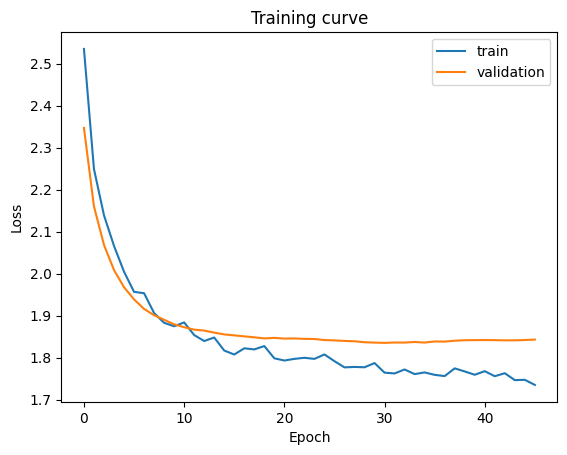

In [7]:
grid = [dict(units=u, dropout=d, lr=l, batch_size=b)
        for u, d, l, b in itertools.product([(32, 16), (64, 32), (128, 64)],
                                            [0.1, 0.3], [1e-3, 5e-4], [32])]
results = []
for cfg in grid:
    m, h = fit(cfg)
    results.append({**cfg, "val_loss": min(h.history["val_loss"])})
res = pd.DataFrame(results).sort_values("val_loss")
print(res)

best = res.iloc[0].to_dict()
best_cfg = dict(units=tuple(best["units"]), dropout=best["dropout"],
                lr=best["lr"], batch_size=int(best["batch_size"]))
print("Best config:", best_cfg)

model, history = fit(best_cfg)
plt.plot(history.history["loss"], label="train"); plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Training curve"); plt.show()

Water intake (L): RMSE = 0.377 | R2 = 0.600
Session duration (h): RMSE = 0.206 | R2 = 0.564

Workout type: accuracy = 0.260 | precision = 0.289 | recall = 0.260 | F1 = 0.257
              precision    recall  f1-score   support

      Cardio       0.28      0.41      0.33        39
        HIIT       0.46      0.18      0.26        33
    Strength       0.18      0.21      0.20        38
        Yoga       0.26      0.22      0.24        36

    accuracy                           0.26       146
   macro avg       0.29      0.26      0.26       146
weighted avg       0.29      0.26      0.26       146



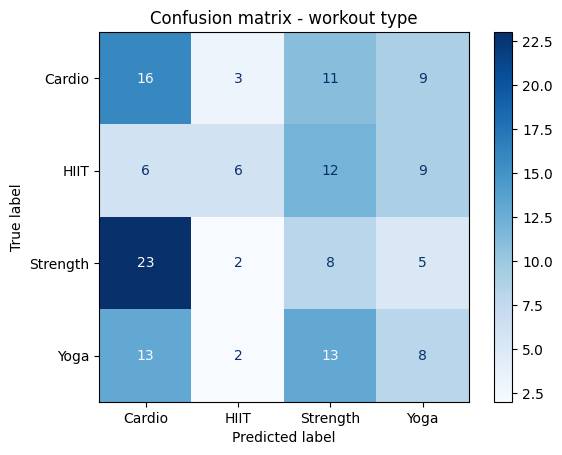

In [8]:
reg_pred, cls_prob = model.predict(Xte, verbose=0)
reg_pred = y_scaler.inverse_transform(reg_pred); reg_true = y_scaler.inverse_transform(Yte)

for i, name in enumerate(["Water intake (L)", "Session duration (h)"]):
    rmse = np.sqrt(mean_squared_error(reg_true[:, i], reg_pred[:, i]))
    print(f"{name}: RMSE = {rmse:.3f} | R2 = {r2_score(reg_true[:, i], reg_pred[:, i]):.3f}")

cls_pred = cls_prob.argmax(axis=1)
p, r, f1, _ = precision_recall_fscore_support(Cte, cls_pred, average="weighted", zero_division=0)
print(f"\nWorkout type: accuracy = {accuracy_score(Cte, cls_pred):.3f} | "
      f"precision = {p:.3f} | recall = {r:.3f} | F1 = {f1:.3f}")
print(classification_report(Cte, cls_pred, target_names=le.classes_, zero_division=0))

ConfusionMatrixDisplay(confusion_matrix(Cte, cls_pred), display_labels=le.classes_).plot(cmap="Blues")
plt.title("Confusion matrix - workout type"); plt.show()

In [9]:
model.save(MODEL_DIR / "fitness_model.keras")
joblib.dump(x_scaler, MODEL_DIR / "x_scaler.joblib")
joblib.dump(y_scaler, MODEL_DIR / "y_scaler.joblib")
json.dump({"workout_classes": list(le.classes_), "features": FEATURES,
           "best_config": {**best_cfg, "units": list(best_cfg["units"])}},
          open(MODEL_DIR / "config.json", "w"), indent=2)
print("Model, scalers and config saved in /model")

Model, scalers and config saved in /model


In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

base = DummyClassifier(strategy="most_frequent").fit(Xtr, Ctr)
rf = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(Xtr, Ctr)
print("Majority-class baseline:", round(accuracy_score(Cte, base.predict(Xte)), 3))
print("Random forest:          ", round(accuracy_score(Cte, rf.predict(Xte)), 3))
print("Our FNN:                ", round(accuracy_score(Cte, cls_pred), 3))

Majority-class baseline: 0.26
Random forest:           0.24
Our FNN:                 0.26


In [11]:
import shutil
from google.colab import files
shutil.copy("fitness_utils.py", "model/fitness_utils.py")   # include the helper file too
shutil.make_archive("personal_fitness_model", "zip", "model")
files.download("personal_fitness_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>